In [1]:
import numpy as np
import sys
import os
import matplotlib.pyplot as plt

np.set_printoptions(threshold=np.inf, linewidth=np.inf)

# Absolute path to the folder that contains "quant_rotor"
sys.path.append("/Users/gilfrim/Desktop/Projects/Computational_Analysis_of_Many_Rotor_Systems")

# One and two body operators
from quant_rotor.Hamiltonian_models.Dense.operators import heisenberg_operators, rotor_operators

# Hamiltonian Constructor
from quant_rotor.Hamiltonian_models.Dense.hamiltonian import hamiltonian_dense

# Basis Changes
from quant_rotor.Hamiltonian_models.Dense.basis_transform import NO_transform, combine_transform ,TF_transform ,energy_transform

# Exact T-amplitude and energy calculations
from quant_rotor.CCC_iterative_methods.Dense.t_amplitudes_exact import t_1_amplitude_guess_ground_state, t_2_amplitude_guess_ground_state, amplitute_energy

# Iterative CCC
from quant_rotor.CCC_iterative_methods.Dense.t_amplitudes_periodic import t_periodic

# Integrator
from quant_rotor.CCC_integration_methods.Dense.de_solve_one_thermal import integration_scheme
from quant_rotor.CCC_integration_methods.Dense.de_solve_one_thermal_dense import integration_scheme as integration_scheme_fast
from quant_rotor.CCC_integration_methods.Dense.stat_mech_thermo import U as U_stat
from quant_rotor.CCC_integration_methods.Dense.stat_mech_thermo import Z as Z_stat
from quant_rotor.CCC_integration_methods.Dense.stat_mech_thermo import S as S_stat
from quant_rotor.CCC_integration_methods.Dense.stat_mech_thermo import A as A_stat
from quant_rotor.CCC_integration_methods.Dense.stat_mech_thermo import Z_new, A_new, S_new

# Rotor Hamiltonian

### Regular Hamiltonian

In [2]:
state = 5
site = 3

g = 0.1
periodic = False

In [3]:
K_rot, V_rot = rotor_operators(state, g)
H_rot = hamiltonian_dense(site, K_rot, V_rot, V_rot, periodic)

In [4]:
eig_val_rot, eig_vec_rot = np.linalg.eigh(H_rot)

### NO hamiltonian transformation

In [5]:
state_NO = 3

In [6]:
K_rot_NO, V_rot_NO, _, _  = NO_transform(state_NO, H_rot, K_rot, V_rot, V_rot)
H_rot_NO = hamiltonian_dense(site, K_rot_NO, V_rot_NO, V_rot_NO, periodic)

In [7]:
eig_val_rot_NO, eig_vec_rot_NO = np.linalg.eigh(H_rot_NO)

### Check The Output

In [8]:
print(eig_val_rot)
print(eig_val_rot_NO)

[-0.01250234  0.85082116  0.92329852  0.99343747  0.99718672  1.06452491  1.13325748  1.85690621  1.88229472  1.88536549  1.9271026   1.99378308  1.99560428  1.99681348  1.998667    2.06801019  2.10572829  2.10896896  2.1391426   2.98915964  2.98916122  2.99402439  2.99403545  2.9958433   2.99585365  3.00434502  3.00434537  3.9951302   3.9957014   3.99688618  3.99688836  4.00739967  4.00798604  4.88200435  4.88274966  4.8857497   4.88665241  4.92965644  4.93104337  4.93140582  4.93237262  4.99860824  4.99923896  4.99961698  4.99998932  5.00169041  5.00379803  5.00422345  5.00694005  5.06914345  5.07055917  5.0706991   5.07193548  5.11758518  5.11838198  5.12123035  5.12209402  5.89023096  5.89023279  5.92188669  5.92189066  5.92190384  5.9219193   5.96747141  5.96752804  5.99527164  5.99546594  5.99731769  5.99742987  5.99838202  5.99857142  6.00275474  6.00285941  6.03807562  6.03813012  6.08003572  6.0800647   6.08006963  6.0800736   6.1020711   6.1020735   8.00025533  8.00046753  8.

### Combined Hamiltonian transformation

In [22]:
site_original = 4
site_combined = 2

state = 3 # We reduce the number of states becasue othervise the system becomes too large.

Construct standard rotor operators.

In [23]:
K_rot, V_rot = rotor_operators(state, g)
H_rot = hamiltonian_dense(site_original, K_rot, V_rot, V_rot, periodic)

In [24]:
eig_val_rot, eig_vec_rot = np.linalg.eigh(H_rot)

Transform to combined basis.

In [ ]:
K_rot_comb, V_rot_comb_xy, V_rot_comb_yx =  combine_transform(site_original, site_combined, K_rot, V_rot, periodic)
H_rot_comb = hamiltonian_dense(site_combined, K_rot_comb, V_rot_comb_xy, V_rot_comb_yx, periodic)

In [26]:
eig_val_rot_comb, eig_vec_rot_comb = np.linalg.eigh(H_rot_comb)

Transform rotor standard basis into NO basis.

In [27]:
K_rot_NO, V_rot_NO, _, _  = NO_transform(state_NO, H_rot, K_rot, V_rot, V_rot)
H_rot_NO = hamiltonian_dense(site_original, K_rot_NO, V_rot_NO, V_rot_NO, periodic)

Transform NO rotor operators into combined basis.

In [ ]:
K_rot_NO_comb, V_rot_NO_comb_xy, V_rot_NO_comb_yx =  combine_transform(site_original, site_combined, K_rot, V_rot, periodic)
H_rot_NO_comb = hamiltonian_dense(site_combined, K_rot_NO_comb, V_rot_NO_comb_xy, V_rot_NO_comb_yx, periodic)

In [29]:
eig_val_rot_NO_comb, eig_vec_rot_NO_comb = np.linalg.eigh(H_rot_NO_comb)

## Check the output

In [36]:
print(eig_val_rot)
print(eig_val_rot_NO_comb)
print(eig_val_rot_comb)

[-0.01871957  0.826175    0.91012439  0.93223084  0.95943633  1.02128658  1.05515109  1.0717262   1.14896987  1.77668144  1.82484481  1.82484481  1.88676906  1.89936305  1.90780543  1.90780543  1.94752693  1.99236788  1.99484802  1.99484802  1.99563308  1.99704835  1.99891854  1.99891854  2.00621434  2.04748551  2.08725922  2.08725922  2.09938773  2.11023711  2.16759366  2.16759366  2.22254409  2.84896179  2.8591057   2.85929902  2.87192236  2.87928932  2.88695012  2.88726209  2.92192236  2.92200465  2.94257991  2.95685845  2.95695103  2.96731801  2.96800667  2.9709467   2.97928932  3.02071068  3.03149085  3.03669921  3.03700393  3.04414505  3.04418701  3.06568524  3.07807764  3.08343738  3.11555877  3.11576129  3.12071068  3.12807764  3.15097722  3.15113716  3.17257246  4.          4.          4.          4.          4.          4.00088883  4.00109572  4.00109572  4.00504716  4.00623514  4.00623514  4.00623677  4.00856404  4.01139947  4.01139947  4.01672418]
[-0.01871957  0.826175    

# Heisenberg Hamiltonian

***IMPORTANT for Heisenberg systems the state is always 2.***

In [39]:
site = 5

J_x = 1
J_y = 1
J_z = 0

h_x = 0
h_y = 0
h_z = -1

g = 0.7

In [40]:
K_heis, V_heis = heisenberg_operators(J_x, J_y, J_z, h_x, h_y, h_z, g)
H_heis = hamiltonian_dense(site, K_heis, V_heis, V_heis, True)

Then constructing the combined hamiltonian is same as for the rotor systems.

# Iterative CCC

In [13]:
state = 3
state_2 = state**2
site = 2

g = 0.1
periodic = False

In [14]:
K_rot, V_rot = rotor_operators(state, g)
H_rot = hamiltonian_dense(site, K_rot, V_rot, V_rot, periodic)

In [17]:
eig_val_rot, eig_vec_rot = np.linalg.eigh(H_rot)

In [18]:
t_1_exact = t_1_amplitude_guess_ground_state(state, site, eig_vec_rot, eig_val_rot)
t_2_exact = t_2_amplitude_guess_ground_state(state, site, eig_vec_rot, eig_val_rot)

In [19]:
E = amplitute_energy(site, state, periodic, K_rot, V_rot.reshape(state, state, state, state), V_rot.reshape(state, state, state, state), np.copy(t_1_exact), np.copy(t_2_exact))

E should be equal to the ground state energy.

In [20]:
E - eig_val_rot[0]

np.complex128(-8.673617379884035e-19+0j)

In [21]:
T_1, T_2, R_1, R_2 = t_periodic(site, state, K_rot, V_rot.reshape(state, state, state, state), V_rot.reshape(state, state, state, state), "original", Import_t=True, t_1_import=np.copy(t_1_exact), t_2_import=np.copy(t_2_exact), periodic=periodic, one_cicle=True)

original


In [22]:
T_1_linked, T_2_linked, R_1_linked, R_2_linked = t_periodic(site, state, K_rot, V_rot.reshape(state, state, state, state), V_rot.reshape(state, state, state, state), "linked", Import_t=True, t_1_import=np.copy(t_1_exact), t_2_import=np.copy(t_2_exact), periodic=periodic, one_cicle=True)

linked


In [23]:
T_1_transformed, T_2_transformed, R_1_transformed, R_2_transformed = t_periodic(site, state, K_rot, V_rot.reshape(state, state, state, state), V_rot.reshape(state, state, state, state), "transformed", Import_t=True, t_1_import=np.copy(t_1_exact), t_2_import=np.copy(t_2_exact), periodic=periodic, one_cicle=True)

transformed


In [24]:
print("Connected/Linked R_1:" ,np.max(np.abs(R_1_linked - R_1)))
print("Connected/Linked R_2:" ,np.max(np.abs(R_2_linked - R_2)), "\n")

print("Connected/Transformed R_1:" ,np.max(np.abs(R_1_transformed - R_1)))
print("Connected/Transformed R_2:" ,np.max(np.abs(R_2_transformed - R_2)), "\n")

print("Linked/Transformed R_1:" ,np.max(np.abs(R_1_transformed - R_1_linked)))
print("Linked/Transformed R_2:" ,np.max(np.abs(R_2_transformed - R_2_linked)))

Connected/Linked R_1: 0.0
Connected/Linked R_2: 0.0 

Connected/Transformed R_1: 0.0
Connected/Transformed R_2: 0.0 

Linked/Transformed R_1: 0.0
Linked/Transformed R_2: 0.0


# TF Integrator

In [25]:
state = 3
state_TF = state**2
site = 2

g = 0.1
periodic = False

In [26]:
K, V = rotor_operators(state, g)
H = hamiltonian_dense(site, K, V, V, periodic)

In [27]:
eig_val, eig_vec = np.linalg.eigh(H)

In [28]:
K_e, V_e, _ = energy_transform(K, V, V)
K_TF, V_TF, _ = TF_transform(K_e, V_e, V_e)

In [29]:
V_TF = V_TF.reshape(state_TF, state_TF, state_TF, state_TF)

In [32]:
i = 1
a = state_TF - i

In [33]:
t_1_tensor = np.zeros((site, a, i), dtype=complex)
t_2_tensor = np.zeros((site, site, a, a, i, i), dtype=complex)

In [34]:
time_TF, energy_TF, t_0_TF, t_1_max_TF = integration_scheme_fast(site, state_TF, K_TF, V_TF, V_TF, periodic=periodic, import_guess=True, t_0_import=np.log(state**site), t_1_import=np.copy(t_1_tensor[0]).reshape(a), t_2_import=np.copy(t_2_tensor).reshape(site, site, a, a))

0.0
0.020606563671912312
0.22667220039103542
0.5392787776141774
0.8663303002062626
1.1856967286577935
1.50953375130388
1.8305804369848726
2.1286478727852938
2.426715308585715
2.700002696105182
3.013186922959323
3.3823596532340905
3.804626530991063
4.212130282998419
4.60260577705771
4.99128426428075
5.391427974479626
5.818447447764085
6.287114992530993
6.787114992530993
7.287114992530993
7.787114992530993
8.287114992530993
8.787114992530993
9.287114992530993
9.787114992530993


In [35]:
time_TF_o, energy_TF_o, t_0_TF_o, t_1_max_TF_o = integration_scheme(site, state_TF, K_TF, V_TF, V_TF, periodic=periodic, import_guess=True, t_0_import=np.log(state**site), t_1_import=np.copy(t_1_tensor), t_2_import=np.copy(t_2_tensor))

0.0
0.01474822851182894
0.16223051363011834
0.6622305136301183
1.1622305136301183
1.6622305136301183
2.162230513630118
2.662230513630118
3.162230513630118
3.662230513630118
4.162230513630118
4.662230513630118
5.162230513630118
5.662230513630118
6.162230513630118
6.662230513630118
7.162230513630118
7.662230513630118
8.162230513630117
8.662230513630117
9.162230513630117
9.662230513630117
266


In [36]:
time, energy, t_0_CCC, one_max_CC = integration_scheme(site, state, K, V.reshape(state, state, state, state), V.reshape(state, state, state, state), periodic=periodic)

0.0
9.999999999999999e-05
0.0011
0.0111
0.1111
0.6111
1.1111
1.6111
2.1111
2.6111
3.1111
3.6111
4.1111
4.6111
5.1111
5.6111
6.1111
6.6111
7.1111
7.6111
8.1111
8.6111
9.1111
9.6111
556


## Graphs

In [37]:
ED_U_val = np.array([U_stat(eig_val, x) for x in time_TF])

In [38]:
ED_Z_val = np.array([Z_stat(eig_val, x) for x in time_TF])

In [39]:
def S_new(t_0, beta: float, U_val: float):
    return (U_val * beta + t_0)

In [40]:
S_val = np.array([S_new(t_0_TF[x], time_TF[x], energy_TF[x]) for x in range(1, time_TF.shape[0])])

In [41]:
ED_S_val = np.array([S_stat(eig_val, x) for x in time_TF])

In [42]:
Z_val = np.array([Z_new(x) for x in t_0_TF])

In [43]:
np.max(np.abs(energy_TF - ED_U_val))

np.float64(0.006323568396955108)

In [44]:
ED_U_val - energy_TF

array([-2.22044605e-16+0.j, -4.41614967e-10+0.j, -4.75707155e-07+0.j, -4.52772341e-06+0.j, -1.53855600e-05+0.j, -4.58873182e-05+0.j, -1.32534338e-04+0.j, -3.20315331e-04+0.j, -6.14001134e-04+0.j, -1.02363860e-03+0.j, -1.48114415e-03+0.j, -2.06308415e-03+0.j, -2.76728382e-03+0.j, -3.52244309e-03+0.j, -4.15207474e-03+0.j, -4.64831824e-03+0.j, -5.04197473e-03+0.j, -5.35614114e-03+0.j, -5.60849147e-03+0.j, -5.81000768e-03+0.j, -5.96202592e-03+0.j, -6.06910183e-03+0.j, -6.14599444e-03+0.j, -6.20291077e-03+0.j, -6.24674924e-03+0.j, -6.28210088e-03+0.j, -6.31198889e-03+0.j, -6.32356840e-03+0.j])

In [45]:
energy_TF[-1] - energy_TF[-2]

np.complex128(-3.7447876796868965e-05+0j)

/Users/gilfrim/Desktop/Projects/Computational_Analysis_of_Many_Rotor_Systems/.venv/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/gilfrim/Desktop/Projects/Computational_Analysis_of_Many_Rotor_Systems/.venv/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


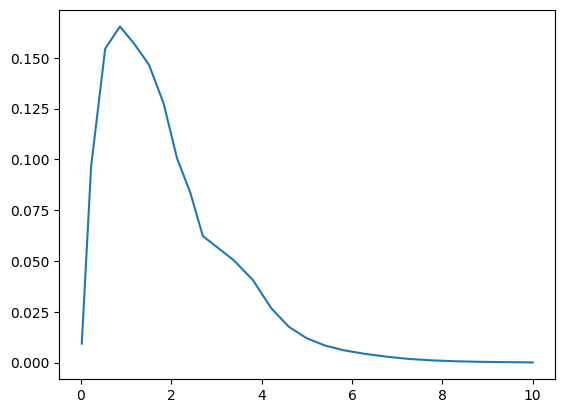

In [46]:
plt.plot(time_TF[1:], energy_TF[:-1] - energy_TF[1:], label=f"TF")
plt.show()

In [59]:
energy_TF - ED_U_val

array([2.22044605e-16+0.j, 4.41614967e-10+0.j, 4.75707155e-07+0.j, 4.52772341e-06+0.j, 1.53855600e-05+0.j, 4.58873182e-05+0.j, 1.32534338e-04+0.j, 3.20315331e-04+0.j, 6.14001134e-04+0.j, 1.02363860e-03+0.j, 1.48114415e-03+0.j, 2.06308415e-03+0.j, 2.76728382e-03+0.j, 3.52244309e-03+0.j, 4.15207474e-03+0.j, 4.64831824e-03+0.j, 5.04197473e-03+0.j, 5.35614114e-03+0.j, 5.60849147e-03+0.j, 5.81000768e-03+0.j, 5.96202592e-03+0.j, 6.06910183e-03+0.j, 6.14599444e-03+0.j, 6.20291077e-03+0.j, 6.24674924e-03+0.j, 6.28210088e-03+0.j, 6.31198889e-03+0.j, 6.32356840e-03+0.j])

/Users/gilfrim/Desktop/Projects/Computational_Analysis_of_Many_Rotor_Systems/.venv/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/gilfrim/Desktop/Projects/Computational_Analysis_of_Many_Rotor_Systems/.venv/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


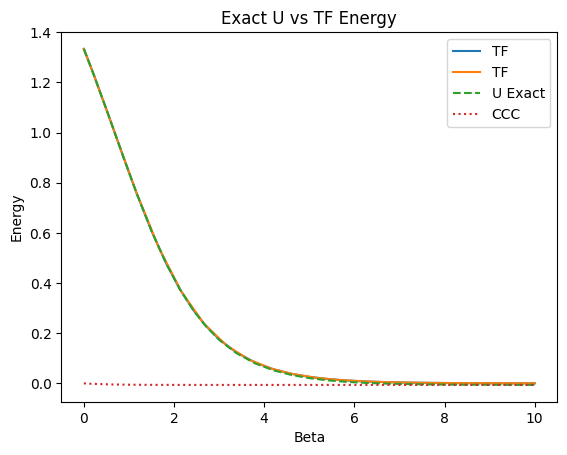

In [54]:
plt.plot(time_TF, energy_TF, label=f"TF")
plt.plot(time_TF_o, energy_TF_o, label=f"TF")
plt.plot(time_TF, ED_U_val, label=f"U Exact", linestyle="--")
plt.plot(time, energy, label=f"CCC", linestyle=":")
plt.title("Exact U vs TF Energy")
plt.xlabel("Beta")
plt.ylabel("Energy")
plt.legend()
plt.show()

In [48]:
Z_val

array([9.        +0.j, 8.75692595+0.j, 6.73175338+0.j, 4.69735976+0.j, 3.39761564+0.j, 2.60760484+0.j, 2.09465446+0.j, 1.76181183+0.j, 1.55218036+0.j, 1.40547519+0.j, 1.30884983+0.j, 1.2290164 +0.j, 1.16400563+0.j, 1.11507458+0.j, 1.08442718+0.j, 1.0649229 +0.j, 1.05183748+0.j, 1.04276723+0.j, 1.03635245+0.j, 1.03182794+0.j, 1.02882732+0.j, 1.02698484+0.j, 1.02584585+0.j, 1.02513357+0.j, 1.02467907+0.j, 1.02437901+0.j, 1.02417002+0.j, 1.02409853+0.j])

In [49]:
Z_val - ED_Z_val

array([ 1.77635684e-15+0.j, -1.99982253e-11+0.j, -1.90713712e-07+0.j, -3.23984512e-06+0.j, -1.24850599e-05+0.j, -3.27895130e-05+0.j, -8.23474183e-05+0.j, -1.91568059e-04+0.j, -3.80292127e-04+0.j, -6.83732984e-04+0.j, -1.08307785e-03+0.j, -1.69860074e-03+0.j, -2.64892186e-03+0.j, -4.02607018e-03+0.j, -5.62269132e-03+0.j, -7.36602208e-03+0.j, -9.27517001e-03+0.j, -1.13888977e-02+0.j, -1.37771945e-02+0.j, -1.65211701e-02+0.j, -1.95563464e-02+0.j, -2.26753257e-02+0.j, -2.58580089e-02+0.j, -2.90903656e-02+0.j, -3.23627648e-02+0.j, -3.56686848e-02+0.j, -3.90037611e-02+0.j, -4.04318379e-02+0.j])

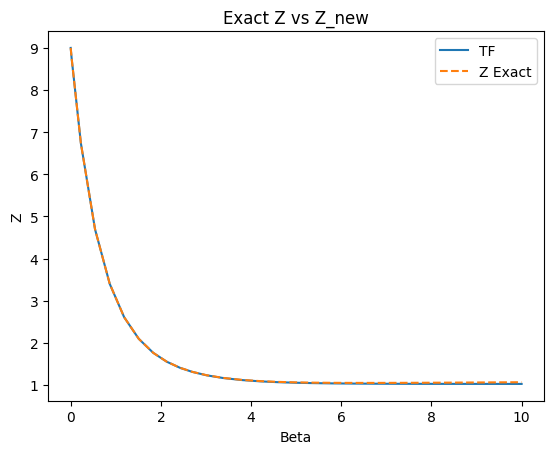

In [50]:
plt.plot(time_TF, Z_val, label=f"TF")
plt.plot(time_TF, ED_Z_val, label=f"Z Exact", linestyle="--")
plt.title("Exact Z vs Z_new")
plt.xlabel("Beta")
plt.ylabel("Z")
plt.legend()
plt.show()

In [51]:
np.max(np.abs(S_val - ED_S_val[1:]))

np.float64(0.024514693839466865)

In [52]:
S_val

array([2.19712859+0.j, 2.18512334+0.j, 2.12575521+0.j, 2.0095075 +0.j, 1.84886643+0.j, 1.65180844+0.j, 1.43913982+0.j, 1.24038265+0.j, 1.05100122+0.j, 0.89163862+0.j, 0.72974331+0.j, 0.56906442+0.j, 0.42335217+0.j, 0.31623286+0.j, 0.23880402+0.j, 0.1810853 +0.j, 0.13720794+0.j, 0.10343036+0.j, 0.07760247+0.j, 0.05911025+0.j, 0.04695936+0.j, 0.03903339+0.j, 0.03390554+0.j, 0.03062308+0.j, 0.02855433+0.j, 0.02728273+0.j, 0.02691241+0.j])

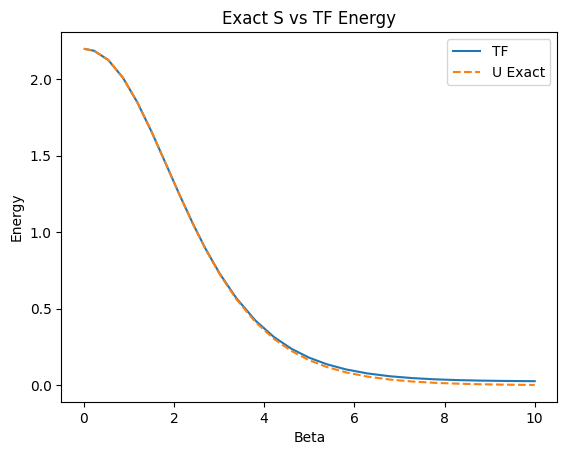

In [53]:
plt.plot(time_TF[1:], S_val, label=f"TF")
plt.plot(time_TF, ED_S_val, label=f"U Exact", linestyle="--")
plt.title("Exact S vs TF Energy")
plt.xlabel("Beta")
plt.ylabel("Energy")
plt.legend()
plt.show()

# Prepare the graph wrapper

Example of the input.

In [17]:
g_range_array = np.array([0.1, 0.2])
psi_twist_array = np.array([0])
site_array = np.array([3])

In [32]:
def graph_func(g_range_array, psi_twist_array, site_array, ED: bool=True, CCC: bool=True, TF: bool=True):

    state = 9
    state_NO = 5
    state_TF = state_NO**2

    periodic = True

    i = 1
    a = state_TF - i

    CCC_vals_psi = []
    TF_vals_psi = []
    ED_stat_psi = []
    TF_stat_psi = []

    CCC_vals_g_psi = []
    TF_vals_g_psi = []
    ED_stat_g_psi = []
    TF_stat_g_psi = []

    CCC_vals_site_g_psi = []
    TF_vals_site_g_psi = []
    ED_stat_site_g_psi = []
    TF_stat_site_g_psi = []

    for site_idx in range(site_array.shape[0]):

        site = site_array[site_idx]

        t_a_i_tensor = np.zeros((a), dtype=complex)
        t_ab_ij_tensor = np.zeros((site, site, a, a), dtype=complex)
        for g_idx in range(g_range_array.shape[0]):
            for psi_twist_idx in range(psi_twist_array.shape[0]):

                g = g_range_array[g_idx]
                psi_twist = psi_twist_array[psi_twist_idx]

                if ED:
                    K, V = rotor_operators(state, g, psi_twist)
                    H = hamiltonian_dense(site, K, V, V, periodic)

                    K_rot_NO, V_rot_NO, _, _  = NO_transform(state_NO, H, K, V, V)
                    H_rot_NO = hamiltonian_dense(site, K_rot_NO, V_rot_NO, V_rot_NO, periodic)

                    eig_val, eig_vec = np.linalg.eigh(H_rot_NO)

                    print("ED Done.")

                if TF:
                    K_e, V_e = rotor_operators(state_NO, g, psi_twist)
                    K_TF, V_TF, _ = TF_transform(K_e, V_e, V_e)

                    time_TF, energy_TF, t_0_TF, _ = integration_scheme_fast(site, state_TF, K_TF, V_TF.reshape(state_TF, state_TF, state_TF, state_TF), V_TF.reshape(state_TF, state_TF, state_TF, state_TF), periodic=periodic, import_guess=True, t_0_import=np.log(state**site), t_1_import=t_a_i_tensor, t_2_import=t_ab_ij_tensor)

                    if CCC:
                        time, energy, t_0_CCC, _ = integration_scheme(site, state_NO, K_e, V_e.reshape(state_NO, state_NO, state_NO, state_NO), V_e.reshape(state_NO, state_NO, state_NO, state_NO), periodic=periodic)

                    print("TF Done.")

                    ED_U_val = np.array([U_stat(eig_val, x) for x in time_TF])
                    ED_Z_val = np.array([Z_stat(eig_val, x) for x in time_TF])
                    ED_S_val = np.array([S_stat(eig_val, x) for x in time_TF])
                    ED_A_val = np.array([A_stat(eig_val, x) for x in time_TF])


                    S_val = np.array([S_new(t_0_TF[x], time_TF[x], energy_TF[x]) for x in range(1, time_TF.shape[0])])
                    Z_val = np.array([Z_new(x) for x in t_0_TF])
                    A_val = np.array([A_new(t_0_TF[x], time_TF[x]) for x in range(1, time_TF.shape[0])])

                    print("Stat Done.")

                CCC_vals_psi.append((time, energy, t_0_CCC))
                TF_vals_psi.append((time_TF, energy_TF, t_0_CCC))
                ED_stat_psi.append((ED_U_val, ED_Z_val, ED_S_val, ED_A_val))
                TF_stat_psi.append((Z_val, S_val, A_val))

            CCC_vals_g_psi.append(CCC_vals_psi)
            TF_vals_g_psi.append(TF_vals_psi)
            ED_stat_g_psi.append(ED_stat_psi)
            TF_stat_g_psi.append(TF_stat_psi)

        CCC_vals_site_g_psi.append(CCC_vals_g_psi)
        TF_vals_site_g_psi.append(TF_vals_g_psi)
        ED_stat_site_g_psi.append(ED_stat_g_psi)
        TF_stat_site_g_psi.append(TF_stat_g_psi)

    return CCC_vals_site_g_psi, TF_vals_site_g_psi, ED_stat_site_g_psi, TF_stat_site_g_psi

In [33]:
CCC_array, TF_array, ED_stat_array, TF_stat_array = graph_func(g_range_array, psi_twist_array, site_array)

ED Done.
0.0
0.005916506631850822
0.06508157295035905
0.18904582689795374
0.31608545883187045
0.4379739720623639
0.5553383227513673
0.6792162504678528
0.8135332677703855
0.9504226928525491
1.0861882388969168
1.2242347520785495
1.3648185588725281
1.505372670824856
1.6438854057872345
1.7797679486135312
1.913134870178822
2.044360529852861
2.174180824373561
2.3042212221285863
2.4366944785036257
2.5707336482427308
2.709627230994019
2.8547544201501935
3.0068545033597176
3.1665340905981143
3.3344660364824934
3.5114808499527403
3.698621604249488
3.897186662014197
4.10877194456276
4.335327842043398
4.579262842909331
4.843666993687092
5.132827263316675
5.453394414846445
5.816629820382424
6.241459447394912
6.741459447394912
7.241459447394912
7.741459447394912
8.241459447394913
8.741459447394913
9.241459447394913
9.741459447394913
0.0
9.999999999999999e-05
0.0011
0.0111
0.1111
0.45506650421373396
0.8304930400149841
1.3304930400149841
1.8304930400149841
2.330493040014984
2.830493040014984
3.3304930

Example of how to deal with the output.

CCC_array[first index is associated with the number of sited from site_array][second index is the g value from the g_range][third index is the psi value from the psi range][third index is you are choosing between beta, energy or t_0]

TF_vals_g_psi - same as CCC_array

ED_stat_array[site index][g index][psi index][index from 0-3 U, Z, S, A]

TF_stat_array[site index][g index][psi index][index from 0-2 Z, S, A]

/Users/gilfrim/Desktop/Projects/Computational_Analysis_of_Many_Rotor_Systems/.venv/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/gilfrim/Desktop/Projects/Computational_Analysis_of_Many_Rotor_Systems/.venv/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


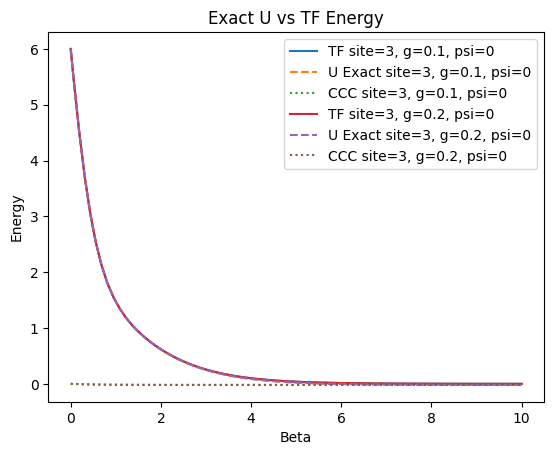

In [35]:
for site_idx in range(site_array.shape[0]):
    for g_idx in range(g_range_array.shape[0]):
        for psi_twist_idx in range(psi_twist_array.shape[0]):
            plt.plot(TF_array[site_idx][g_idx][psi_twist_idx][0], TF_array[site_idx][g_idx][psi_twist_idx][1], label=f"TF site={site_array[site_idx]}, g={g_range_array[g_idx]}, psi={psi_twist_array[psi_twist_idx]}")
            plt.plot(TF_array[site_idx][g_idx][psi_twist_idx][0], ED_stat_array[site_idx][g_idx][psi_twist_idx][0], label=f"U Exact site={site_array[site_idx]}, g={g_range_array[g_idx]}, psi={psi_twist_array[psi_twist_idx]}", linestyle="--")
            plt.plot(CCC_array[site_idx][g_idx][psi_twist_idx][0], CCC_array[site_idx][g_idx][psi_twist_idx][1], label=f"CCC site={site_array[site_idx]}, g={g_range_array[g_idx]}, psi={psi_twist_array[psi_twist_idx]}", linestyle=":")
plt.title("Exact U vs TF Energy")
plt.xlabel("Beta")
plt.ylabel("Energy")
plt.legend()
plt.show()